In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("Wholesale customers data.csv")

In [3]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
df.shape

(440, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [6]:
df.shape

(440, 8)

In [7]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

In [8]:
df['Channel'].value_counts()

Channel
1    298
2    142
Name: count, dtype: int64

In [9]:
df['Region'].value_counts()

Region
3    316
1     77
2     47
Name: count, dtype: int64

In [11]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [12]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [13]:
X = df[['Fresh',
        'Milk',
        'Grocery',
        'Frozen',
        'Detergents_Paper',
        'Delicassen']]

In [14]:
print(X.shape)

(440, 6)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [16]:
print(type(X_scaled))

<class 'numpy.ndarray'>


In [17]:
print(X_scaled.shape)

(440, 6)


In [18]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [19]:
print(pca.explained_variance_ratio_)

[0.44082893 0.283764   0.12334413 0.09395504 0.04761272 0.01049519]


In [20]:
print(sum(pca.explained_variance_ratio_))

0.9999999999999999


In [21]:
import numpy as np

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print(cumulative_variance)

[0.44082893 0.72459292 0.84793705 0.94189209 0.98950481 1.        ]


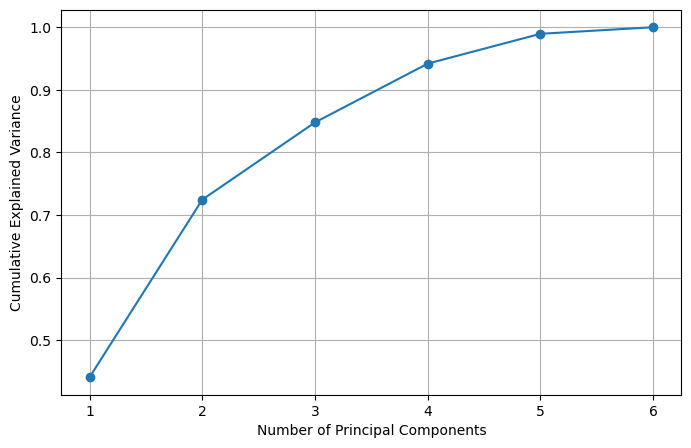

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1,7),
         cumulative_variance,
         marker='o')

plt.xlabel("Number of Principal Components")

plt.ylabel("Cumulative Explained Variance")

plt.grid(True)

plt.show()

In [23]:
pca = PCA(n_components=4)

X_reduced = pca.fit_transform(X_scaled)

In [24]:
pca_df = pd.DataFrame(
    X_reduced,
    columns=['PC1','PC2','PC3','PC4']
)

pca_df.head()

,PC1,PC2,PC3,PC4
0,0.193291,-0.305100,0.140878,-0.486432
1,0.434420,-0.328413,-0.319007,-0.178830
2,0.811143,0.815096,-1.523416,-1.254082
3,-0.778648,0.652754,-0.163012,0.380060
4,0.166287,1.271434,-0.066279,-0.826227


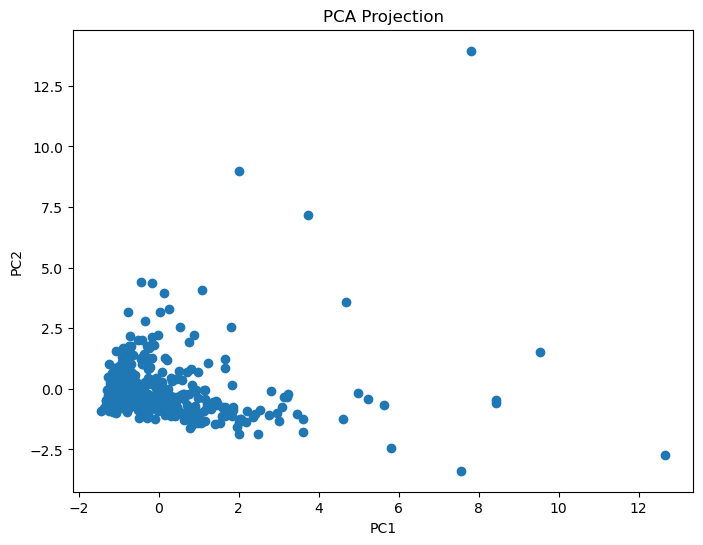

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_reduced[:,0],
    X_reduced[:,1]
)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("PCA Projection")

plt.show()

In [26]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1','PC2','PC3','PC4'],
    index=X.columns
)

print(loadings)

                       PC1       PC2       PC3       PC4
Fresh             0.042884  0.527932  0.812257 -0.236686
Milk              0.545118  0.083168 -0.060388 -0.087190
Grocery           0.579256 -0.146088  0.108384  0.105987
Frozen            0.051189  0.611278 -0.178386  0.768683
Detergents_Paper  0.548640 -0.255233  0.136192  0.171744
Delicassen        0.248682  0.504207 -0.523904 -0.552065


In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(440, 3)


In [28]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.44082893 0.283764   0.12334413]
0.8479370530453145


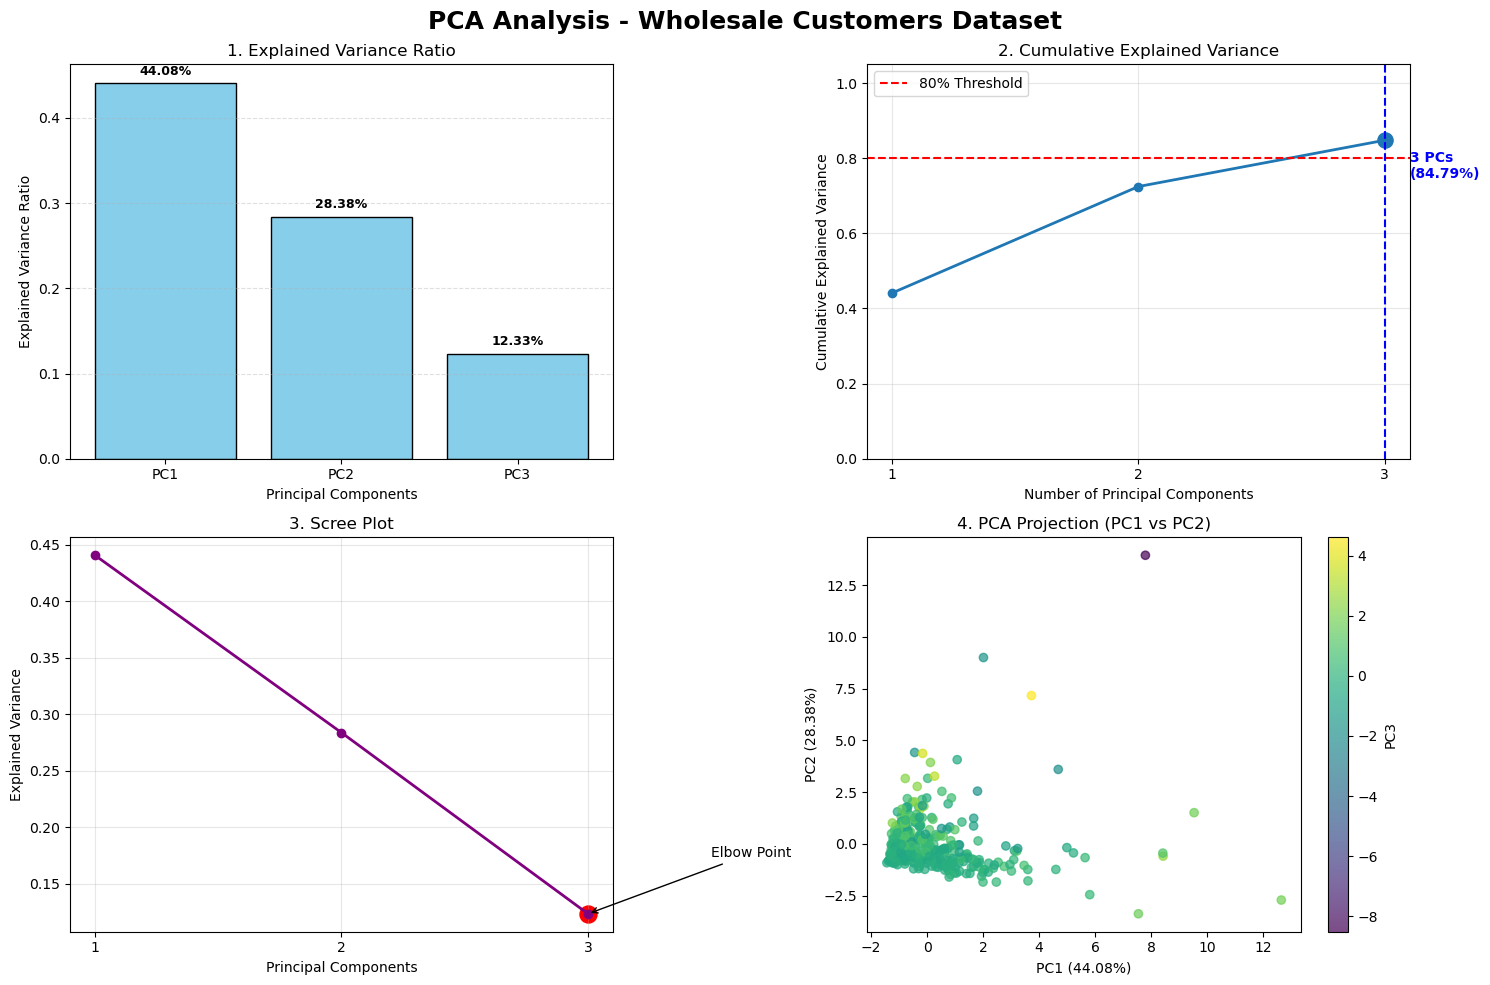

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Number of principal components
n_components = len(explained_variance)

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("PCA Analysis - Wholesale Customers Dataset",
             fontsize=18,
             fontweight='bold')

# =====================================================
# 1. Explained Variance Ratio
# =====================================================
ax = axes[0, 0]

bars = ax.bar(range(1, n_components + 1),
              explained_variance,
              color='skyblue',
              edgecolor='black')

ax.set_title("1. Explained Variance Ratio")
ax.set_xlabel("Principal Components")
ax.set_ylabel("Explained Variance Ratio")
ax.set_xticks(range(1, n_components + 1))
ax.set_xticklabels([f"PC{i}" for i in range(1, n_components + 1)])
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Add percentage labels
for bar, value in zip(bars, explained_variance):
    ax.text(bar.get_x() + bar.get_width()/2,
            value + 0.01,
            f"{value*100:.2f}%",
            ha='center',
            fontsize=9,
            fontweight='bold')

# =====================================================
# 2. Cumulative Explained Variance
# =====================================================
ax = axes[0, 1]

ax.plot(range(1, n_components + 1),
        cumulative_variance,
        marker='o',
        linewidth=2)

ax.axhline(y=0.80,
           color='red',
           linestyle='--',
           label='80% Threshold')

# Highlight selected components
selected = np.argmax(cumulative_variance >= 0.80) + 1

ax.axvline(selected,
           color='blue',
           linestyle='--')

ax.scatter(selected,
           cumulative_variance[selected-1],
           s=120)

ax.text(selected + 0.1,
        cumulative_variance[selected-1]-0.1,
        f"{selected} PCs\n({cumulative_variance[selected-1]*100:.2f}%)",
        color='blue',
        fontsize=10,
        fontweight='bold')

ax.set_title("2. Cumulative Explained Variance")
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_xticks(range(1, n_components + 1))
ax.set_ylim(0,1.05)
ax.grid(alpha=0.3)
ax.legend()

# =====================================================
# 3. Scree Plot
# =====================================================
ax = axes[1,0]

ax.plot(range(1, n_components+1),
        explained_variance,
        marker='o',
        linewidth=2,
        color='purple')

ax.scatter(selected,
           explained_variance[selected-1],
           color='red',
           s=150)

ax.annotate("Elbow Point",
            xy=(selected, explained_variance[selected-1]),
            xytext=(selected+0.5,
                    explained_variance[selected-1]+0.05),
            arrowprops=dict(arrowstyle="->"))

ax.set_title("3. Scree Plot")
ax.set_xlabel("Principal Components")
ax.set_ylabel("Explained Variance")
ax.set_xticks(range(1, n_components+1))
ax.grid(alpha=0.3)

# =====================================================
# 4. PCA Projection
# =====================================================
ax = axes[1,1]

scatter = ax.scatter(X_pca[:,0],
                     X_pca[:,1],
                     c=X_pca[:,2],
                     cmap='viridis',
                     alpha=0.7)

ax.set_title("4. PCA Projection (PC1 vs PC2)")
ax.set_xlabel(f"PC1 ({explained_variance[0]*100:.2f}%)")
ax.set_ylabel(f"PC2 ({explained_variance[1]*100:.2f}%)")

plt.colorbar(scatter,
             ax=ax,
             label="PC3")

plt.tight_layout()
plt.show()